In [45]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

import json
import pandas as pd
import os

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [7]:
transform_base = transforms.Compose([
    transforms.ToTensor()
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor()
])

transform_resnet = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

In [21]:
train_dataset = datasets.STL10(
    root=".",
    split="train",
    download=True,
    transform=transform_base
)

test_dataset = datasets.STL10(
    root=".",
    split="test",
    download=True,
    transform=transform_base
)

train_dataset_aug = datasets.STL10(
    root=".",
    split="train",
    download=True,
    transform=transform_aug
)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset_aug, val_dataset_aug = random_split(
    train_dataset_aug,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [22]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=batch_size)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 4000
Val size: 1000
Test size: 8000


In [23]:
images, labels = next(iter(train_loader))

print("x.shape:", images.shape)
print("y.shape:", labels.shape)

x.shape: torch.Size([64, 3, 96, 96])
y.shape: torch.Size([64])


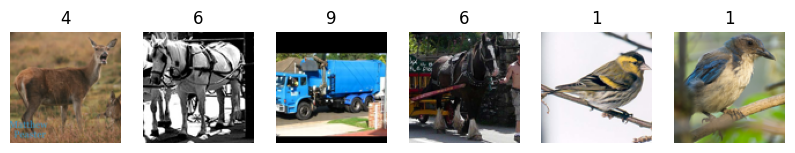

In [24]:
def show_images(images, labels, n=6):
    plt.figure(figsize=(10,4))
    for i in range(n):
        plt.subplot(1,n,i+1)
        img = images[i].permute(1,2,0)
        plt.imshow(img)
        plt.title(labels[i].item())
        plt.axis("off")
    plt.show()

show_images(images, labels)

In [25]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*12*12,256),
            nn.ReLU(),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [26]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x,y in loader:

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs,y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    acc = correct / total

    return total_loss/len(loader), acc

In [27]:
def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            loss = criterion(outputs,y)

            total_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    acc = correct / total

    return total_loss/len(loader), acc

In [28]:
best_val_accuracy = 0
best_model_state = None
best_exp = None

In [32]:
model_c1 = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_c1.parameters(), lr=1e-3)
epochs = 6

history_c1 = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_c1, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_c1, val_loader, criterion)
    history_c1["train_loss"].append(train_loss)
    history_c1["val_loss"].append(val_loss)
    history_c1["train_acc"].append(train_acc)
    history_c1["val_acc"].append(val_acc)
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = model_c1.state_dict()
        best_exp = "C1"
    print(f"Epoch {epoch+1}/{epochs} - train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/6 - train_acc: 0.2375, val_acc: 0.3660
Epoch 2/6 - train_acc: 0.4455, val_acc: 0.4360
Epoch 3/6 - train_acc: 0.5230, val_acc: 0.5060
Epoch 4/6 - train_acc: 0.6070, val_acc: 0.5310
Epoch 5/6 - train_acc: 0.6753, val_acc: 0.5280
Epoch 6/6 - train_acc: 0.7458, val_acc: 0.5500


In [33]:
model_c2 = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model_c2.parameters(), lr=1e-3)

history_c2 = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model_c2, train_loader_aug, optimizer, criterion)
    val_loss, val_acc = evaluate(model_c2, val_loader_aug, criterion)
    history_c2["train_loss"].append(train_loss)
    history_c2["val_loss"].append(val_loss)
    history_c2["train_acc"].append(train_acc)
    history_c2["val_acc"].append(val_acc)
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = model_c2.state_dict()
        best_exp = "C2"
    print(f"Epoch {epoch+1}/{epochs} - train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/6 - train_acc: 0.2627, val_acc: 0.3360
Epoch 2/6 - train_acc: 0.3970, val_acc: 0.3970
Epoch 3/6 - train_acc: 0.4455, val_acc: 0.4840
Epoch 4/6 - train_acc: 0.4990, val_acc: 0.4820
Epoch 5/6 - train_acc: 0.5290, val_acc: 0.5310
Epoch 6/6 - train_acc: 0.5700, val_acc: 0.4980


In [34]:
resnet_c3 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in resnet_c3.parameters():
    param.requires_grad = False
resnet_c3.fc = nn.Linear(resnet_c3.fc.in_features, 10)
resnet_c3 = resnet_c3.to(device)

optimizer = torch.optim.Adam(resnet_c3.fc.parameters(), lr=1e-3)
train_loader_resnet = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_resnet = DataLoader(val_dataset, batch_size=batch_size)

history_c3 = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(resnet_c3, train_loader_resnet, optimizer, criterion)
    val_loss, val_acc = evaluate(resnet_c3, val_loader_resnet, criterion)
    history_c3["train_loss"].append(train_loss)
    history_c3["val_loss"].append(val_loss)
    history_c3["train_acc"].append(train_acc)
    history_c3["val_acc"].append(val_acc)
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = resnet_c3.state_dict()
        best_exp = "C3"
    print(f"Epoch {epoch+1}/{epochs} - train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Epoch 1/6 - train_acc: 0.5225, val_acc: 0.7190
Epoch 2/6 - train_acc: 0.7382, val_acc: 0.7740
Epoch 3/6 - train_acc: 0.7833, val_acc: 0.7780
Epoch 4/6 - train_acc: 0.8040, val_acc: 0.7960
Epoch 5/6 - train_acc: 0.8083, val_acc: 0.7860
Epoch 6/6 - train_acc: 0.8190, val_acc: 0.7760


In [35]:
resnet_c4 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for name,param in resnet_c4.named_parameters():
    param.requires_grad = False
for param in resnet_c4.layer4.parameters():
    param.requires_grad = True
resnet_c4.fc = nn.Linear(resnet_c4.fc.in_features, 10)
resnet_c4 = resnet_c4.to(device)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_c4.parameters()), lr=1e-4)
train_loader_resnet = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_resnet = DataLoader(val_dataset, batch_size=batch_size)

history_c4 = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(resnet_c4, train_loader_resnet, optimizer, criterion)
    val_loss, val_acc = evaluate(resnet_c4, val_loader_resnet, criterion)
    history_c4["train_loss"].append(train_loss)
    history_c4["val_loss"].append(val_loss)
    history_c4["train_acc"].append(train_acc)
    history_c4["val_acc"].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = resnet_c4.state_dict()
        best_exp = "C4"
    print(f"Epoch {epoch+1}/{epochs} - train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/6 - train_acc: 0.6775, val_acc: 0.8300
Epoch 2/6 - train_acc: 0.9417, val_acc: 0.8490
Epoch 3/6 - train_acc: 0.9902, val_acc: 0.8610
Epoch 4/6 - train_acc: 0.9972, val_acc: 0.8690
Epoch 5/6 - train_acc: 0.9998, val_acc: 0.8670
Epoch 6/6 - train_acc: 1.0000, val_acc: 0.8690


In [38]:
val_accs = {
    "C1": max(history_c1["val_acc"]),
    "C2": max(history_c2["val_acc"]),
    "C3": max(history_c3["val_acc"]),
    "C4": max(history_c4["val_acc"])
}

best_exp = max(val_accs, key=val_accs.get)
print("Best model by val accuracy:", best_exp)

best_model = {"C1": model_c1, "C2": model_c2, "C3": resnet_c3, "C4": resnet_c4}[best_exp]
best_history = {"C1": history_c1, "C2": history_c2, "C3": history_c3, "C4": history_c4}[best_exp]

best_test_acc = evaluate(best_model, test_loader, criterion)[1]
print(f"Test accuracy of best model ({best_exp}): {best_test_acc:.4f}")

os.makedirs("artifacts", exist_ok=True)
torch.save(best_model.state_dict(), "artifacts/best_classifier.pt")

best_config = {
    "experiment": best_exp,
    "dataset": "STL10",
    "seed": 42,
    "batch_size": batch_size,
    "epochs": epochs,
    "optimizer": "Adam",
    "lr": 1e-3 if best_exp in ["C1","C2","C3"] else 1e-4,
    "transforms": "augmentations" if best_exp=="C2" else "base",
}
with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

Best model by val accuracy: C4
Test accuracy of best model (C4): 0.8655


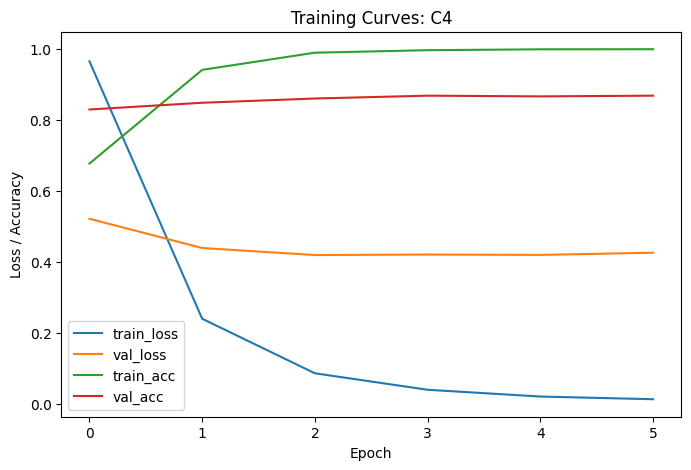

In [39]:
os.makedirs("artifacts/figures", exist_ok=True)

plt.figure(figsize=(8,5))
plt.plot(best_history["train_loss"], label="train_loss")
plt.plot(best_history["val_loss"], label="val_loss")
plt.plot(best_history["train_acc"], label="train_acc")
plt.plot(best_history["val_acc"], label="val_acc")
plt.legend()
plt.title(f"Training Curves: {best_exp}")
plt.xlabel("Epoch")
plt.ylabel("Loss / Accuracy")
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.show()

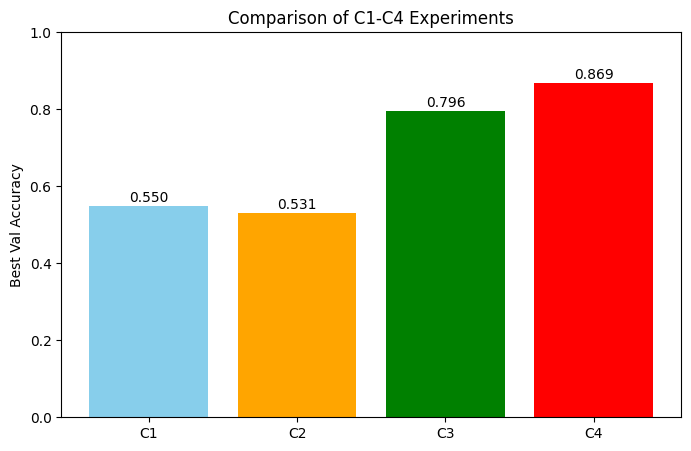

In [40]:
best_val_accs = [
    max(history_c1["val_acc"]),
    max(history_c2["val_acc"]),
    max(history_c3["val_acc"]),
    max(history_c4["val_acc"])
]
experiments = ["C1", "C2", "C3", "C4"]

plt.figure(figsize=(8,5))
plt.bar(experiments, best_val_accs, color=['skyblue','orange','green','red'])
plt.ylabel("Best Val Accuracy")
plt.title("Comparison of C1-C4 Experiments")
for i, v in enumerate(best_val_accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.ylim(0,1)
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

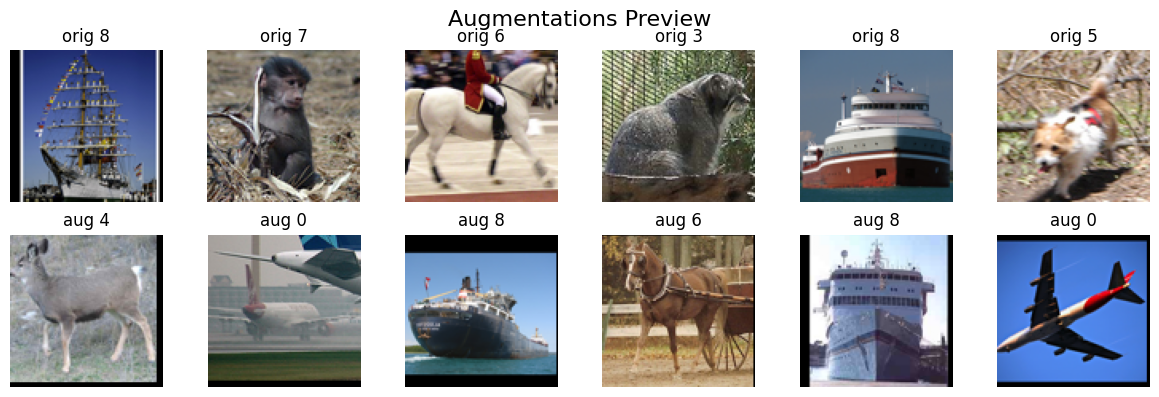

In [41]:
images, labels = next(iter(train_loader))
images_aug, labels_aug = next(iter(train_loader_aug))

plt.figure(figsize=(12,4))
n = 6
for i in range(n):
    # оригинал
    plt.subplot(2,n,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"orig {labels[i].item()}")
    plt.axis("off")
    
    # аугмент
    plt.subplot(2,n,n+i+1)
    plt.imshow(images_aug[i].permute(1,2,0))
    plt.title(f"aug {labels_aug[i].item()}")
    plt.axis("off")

plt.suptitle("Augmentations Preview", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.savefig("artifacts/figures/augmentations_preview.png")
plt.show()

In [47]:
pet_val = datasets.OxfordIIITPet(
    root=".", 
    split="test", 
    target_types="segmentation", 
    download=True,
    transform=transforms.ToTensor(),
    target_transform=transforms.ToTensor()
)

val_loader = DataLoader(pet_val, batch_size=1, shuffle=False)
print("Number of validation images:", len(pet_val))

100.0%
100.0%


Number of validation images: 3669


Sanity-check:
Example image shape: torch.Size([225, 300, 3])
Example mask shape: torch.Size([225, 300])


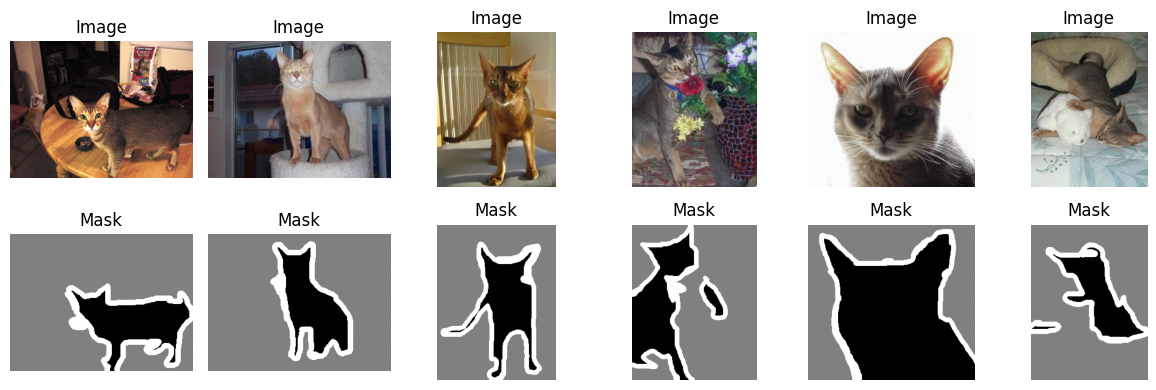

In [49]:
images, masks = [], []
n_samples = 6
for i in range(n_samples):
    img, mask = pet_val[i]
    images.append(img.permute(1,2,0))
    masks.append(mask[0])

print("Sanity-check:")
print("Example image shape:", images[0].shape)
print("Example mask shape:", masks[0].shape)

plt.figure(figsize=(12,4))
for i in range(n_samples):
    plt.subplot(2, n_samples, i+1)
    plt.imshow(images[i])
    plt.axis("off")
    plt.title("Image")
    plt.subplot(2, n_samples, n_samples+i+1)
    plt.imshow(masks[i], cmap='gray')
    plt.axis("off")
    plt.title("Mask")
plt.tight_layout()
plt.show()

In [59]:
from torchvision.models.segmentation import deeplabv3_resnet50

model_seg = deeplabv3_resnet50(weights="DEFAULT").to(device)
model_seg.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [102]:
def segment_image_fg(model, loader, n_samples=5, threshold=0.5):
    images_list, gt_list, preds_list = [], [], []

    for i, (img, target) in enumerate(loader):
        if i >= n_samples:
            break
        img_tensor = img.to(device)
        with torch.no_grad():
            output = model(img_tensor)['out']
        mask_pred = output.argmax(1)[0].cpu()
        mask_bin = (mask_pred > threshold).float()
        images_list.append(img[0].permute(1,2,0).cpu())
        gt_bin = (target[0] > 0).float().cpu()
        gt_list.append(gt_bin)
        preds_list.append(mask_bin)
    return images_list, gt_list, preds_list

In [103]:
def show_segmentation(images, gts, preds, n=5):
    plt.figure(figsize=(12,4))
    for i in range(n):
        plt.subplot(3,n,i+1)
        plt.imshow(images[i])
        plt.axis("off")
        plt.title("Image")
        
        plt.subplot(3,n,n+i+1)
        plt.imshow(gts[i].squeeze(), cmap='gray')
        plt.axis("off")
        plt.title("GT mask")
        
        plt.subplot(3,n,2*n+i+1)
        plt.imshow(preds[i].squeeze(), cmap='gray')
        plt.axis("off")
        plt.title("Pred mask")
    plt.tight_layout()
    plt.savefig("artifacts/figures/segmentation_examples.png")
    plt.show()

In [104]:
def compute_seg_metrics(preds_list, gts_list):
    ious = []
    TP = FP = FN = 0
    for pred, gt in zip(preds_list, gts_list):
        pred_flat = pred.view(-1)
        gt_flat = gt.view(-1)

        intersection = (pred_flat * gt_flat).sum().item()
        union = ((pred_flat + gt_flat) >= 1).sum().item()
        iou = intersection / (union + 1e-6)
        ious.append(iou)

        TP += intersection
        FP += (pred_flat*(1-gt_flat)).sum().item()
        FN += ((1-pred_flat)*gt_flat).sum().item()

    mean_iou = np.mean(ious)
    pixel_precision = TP / (TP + FP + 1e-6)
    pixel_recall = TP / (TP + FN + 1e-6)
    return mean_iou, pixel_precision, pixel_recall

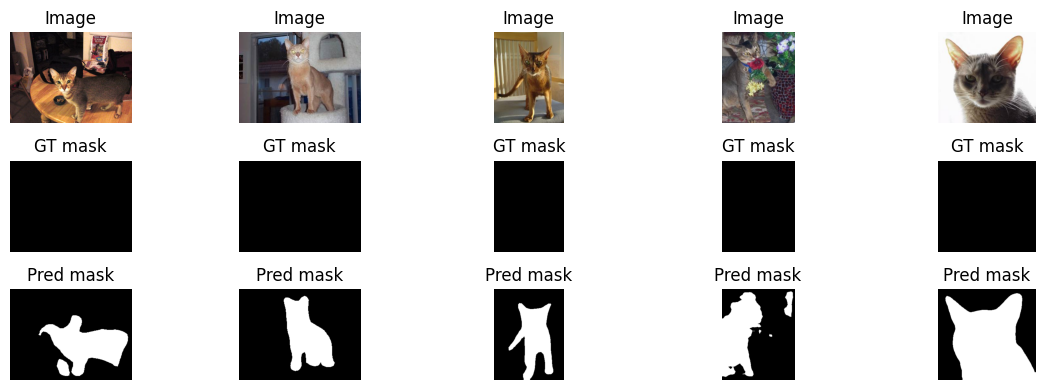

V1 - mean IoU: 0.277, pixel precision: 1.000, pixel recall: 0.296


In [105]:
images_v1, gt_v1, preds_v1 = segment_image_fg(model_seg, val_loader, n_samples=6)
show_segmentation(images_v1, gt_v1, preds_v1)
mean_iou_v1, pixel_precision_v1, pixel_recall_v1 = compute_seg_metrics(preds_v1, gt_v1)
print(f"V1 - mean IoU: {mean_iou_v1:.3f}, pixel precision: {pixel_precision_v1:.3f}, pixel recall: {pixel_recall_v1:.3f}")

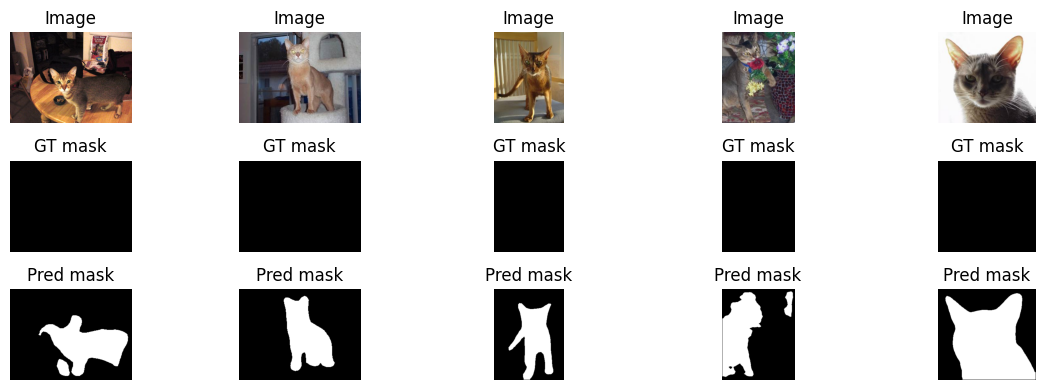

V2 - mean IoU: 0.276, pixel precision: 1.000, pixel recall: 0.295


In [106]:
from scipy.ndimage import binary_opening, binary_closing

def remove_small_and_clean(mask, min_size=300):
    mask_np = mask.numpy()
    mask_np = binary_opening(mask_np)
    mask_np = binary_closing(mask_np)  # закрываем дырки внутри объекта
    labeled, num_features = label(mask_np)
    out_mask = torch.zeros_like(mask)
    for i in range(1, num_features+1):
        component = (labeled == i)
        if component.sum() >= min_size:
            out_mask[component] = 1.0
    return out_mask

images_v2, gt_v2, preds_v2 = segment_image_fg(model_seg, val_loader, n_samples=6, threshold=0.7)
preds_v2 = [remove_small_and_clean(pred) for pred in preds_v2]

show_segmentation(images_v2, gt_v2, preds_v2)
mean_iou_v2, pixel_precision_v2, pixel_recall_v2 = compute_seg_metrics(preds_v2, gt_v2)
print(f"V2 - mean IoU: {mean_iou_v2:.3f}, pixel precision: {pixel_precision_v2:.3f}, pixel recall: {pixel_recall_v2:.3f}")

In [92]:
experiments_data = [
    {"experiment_id":"C1","task":"classification","dataset":"STL10","seed":42,
     "model_summary":str(model_c1),"optimizer":"Adam","lr":1e-3,"epochs_trained":epochs,
     "best_val_accuracy":max(history_c1["val_acc"]),
     "test_accuracy": best_test_acc if best_exp=="C1" else "",
     "precision":"","recall":"","mean_iou":"","notes":"SimpleCNN base"},
    
    {"experiment_id":"C2","task":"classification","dataset":"STL10","seed":42,
     "model_summary":str(model_c2),"optimizer":"Adam","lr":1e-3,"epochs_trained":epochs,
     "best_val_accuracy":max(history_c2["val_acc"]),
     "test_accuracy": best_test_acc if best_exp=="C2" else "",
     "precision":"","recall":"","mean_iou":"","notes":"SimpleCNN with augmentations"},
    
    {"experiment_id":"C3","task":"classification","dataset":"STL10","seed":42,
     "model_summary":str(resnet_c3),"optimizer":"Adam","lr":1e-3,"epochs_trained":epochs,
     "best_val_accuracy":max(history_c3["val_acc"]),
     "test_accuracy": best_test_acc if best_exp=="C3" else "",
     "precision":"","recall":"","mean_iou":"","notes":"ResNet18 head-only"},
    
    {"experiment_id":"C4","task":"classification","dataset":"STL10","seed":42,
     "model_summary":str(resnet_c4),"optimizer":"Adam","lr":1e-4,"epochs_trained":epochs,
     "best_val_accuracy":max(history_c4["val_acc"]),
     "test_accuracy": best_test_acc if best_exp=="C4" else "",
     "precision":"","recall":"","mean_iou":"","notes":"ResNet18 fine-tune layer4+fc"},
    {
        "experiment_id": "V1",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": 42,
        "model_summary": str(model_seg),
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": pixel_precision_v1,
        "recall": pixel_recall_v1,
        "mean_iou": mean_iou_v1,
        "notes": "DeepLabV3 pretrained, basic inference"
    },
    {
        "experiment_id": "V2",
        "task": "segmentation",
        "dataset": "OxfordIIITPet",
        "seed": 42,
        "model_summary": str(model_seg),
        "optimizer": "",
        "lr": "",
        "epochs_trained": "",
        "best_val_accuracy": "",
        "test_accuracy": "",
        "precision": pixel_precision_v2,
        "recall": pixel_recall_v2,
        "mean_iou": mean_iou_v2,
        "notes": "DeepLabV3 pretrained, remove small components"
    }
]

df = pd.DataFrame(experiments_data)
df.to_csv("artifacts/runs.csv", index=False)

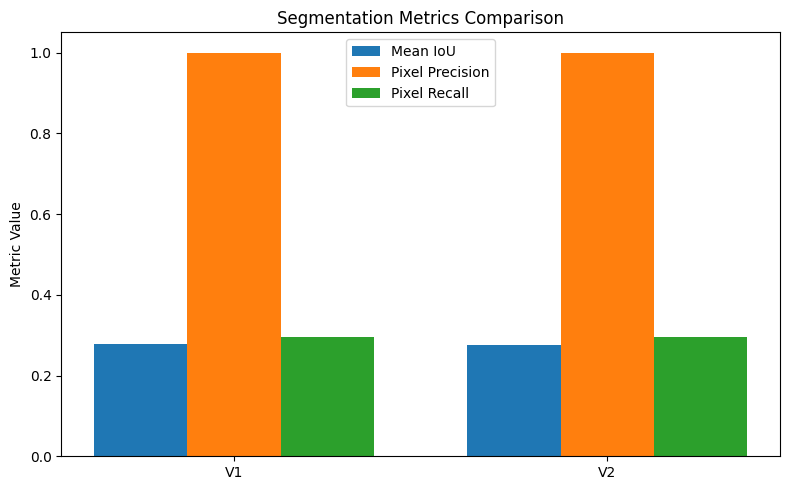

In [93]:
experiments = ["V1", "V2"]
mean_ious = [mean_iou_v1, mean_iou_v2]
precisions = [pixel_precision_v1, pixel_precision_v2]
recalls = [pixel_recall_v1, pixel_recall_v2]

x = np.arange(len(experiments))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, mean_ious, width, label="Mean IoU")
plt.bar(x, precisions, width, label="Pixel Precision")
plt.bar(x + width, recalls, width, label="Pixel Recall")

plt.xticks(x, experiments)
plt.ylabel("Metric Value")
plt.ylim(0,1.05)
plt.title("Segmentation Metrics Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png")
plt.show()